#### Sample Verbosity Score

In [1]:
import re

def score_IC(text):
    return 25 if re.search(r"\b(move left|move right|proceed|stop|go around)\b", text.lower()) else 0

def score_ODC(text):
    # noun/adjective heuristics
    nouns = re.findall(r"\b(chair|cone|bench|dog|cat|person|bag|purse|pole|railing|plant)\b", text.lower())
    adjs = re.findall(r"\b(blue|brown|large|small|folding|metal|wooden)\b", text.lower())
    detail = len(nouns) + len(adjs)
    return min(25, detail * 5)  
    # more detail → higher score

def score_SRC(text):
    return 25 if re.search(r"\b(left|center|right|middle|behind|in front)\b", text.lower()) else 0

def score_RC(text):
    return 25 if re.search(r"\b(because|to avoid|to prevent|so that)\b", text.lower()) else 0

def verbosity_score(text):
    return (score_IC(text) + score_ODC(text) + score_SRC(text) + score_RC(text)) 


### Load all 3 datasets

In [33]:
import pandas as pd

# Load modes — trim to first 311 rows
speed = pd.read_csv("/Users/rianachatterjee/Downloads/in-lab/output_dir/speed_mode_results_vlm.csv")
balance = pd.read_csv("/Users/rianachatterjee/Downloads/in-lab/output_dir/balance_mode_results_vlm.csv")
desc = pd.read_csv("/Users/rianachatterjee/Downloads/in-lab/output_dir/descriptive_mode_results_vlm.csv")

speed["mode"] = "speed"
balance["mode"] = "balance"
desc["mode"] = "descriptive"

df = pd.concat([speed, balance, desc], ignore_index=True)

# Load ground truth & trim
gt = pd.read_csv("/Users/rianachatterjee/Downloads/in-lab/output_dir/general_yolo_results_vlm.csv")


### Merge Each Mode with Ground-Truth

In [34]:
df_merged = df.merge(gt, on="frame", suffixes=("", "_gt"))
df_merged.head()


,frame,object_name,yolo_confidence,depth_ft,used_vlm,output_text,latency_ms,direction,mode,object_name_gt,yolo_confidence_gt,depth_ft_gt,used_vlm_gt,output_text_gt,latency_ms_gt,direction_gt
0,1,person,0.263,29.48,0,[FAST MODE - HIGH CONF],1066.97,left,speed,person,0.263,29.48,0,[FAST MODE - HIGH CONF],2147.90,left
1,2,bench,0.261,28.80,0,[FAST MODE - HIGH CONF],152.72,left,speed,bench,0.261,28.80,0,[FAST MODE - HIGH CONF],420.66,left
2,3,person,0.289,30.83,0,[FAST MODE - HIGH CONF],123.15,left,speed,person,0.289,30.83,0,[FAST MODE - HIGH CONF],275.93,left
3,4,person,0.278,30.19,0,[FAST MODE - HIGH CONF],101.27,left,speed,person,0.278,30.19,0,[FAST MODE - HIGH CONF],166.37,left
4,5,person,0.260,30.15,0,[FAST MODE - HIGH CONF],113.33,left,speed,person,0.260,30.15,0,[FAST MODE - HIGH CONF],184.26,left


### Object Name Accuracy

In [35]:
df_merged["object_match"] = (df_merged["object_name"].str.lower() 
                             == df_merged["object_name_gt"].str.lower()).astype(int)


#### Location Accuracy

In [36]:
import re

def extract_location(text):
    text = str(text).lower()
    if "left" in text:
        return "left"
    if "right" in text:
        return "right"
    if "center" in text or "middle" in text:
        return "center"
    return "none"


In [37]:
df_merged["location_pred"] = df_merged["output_text"].apply(extract_location)
df_merged["location_match"] = (df_merged["location_pred"] == df_merged["direction_gt"].str.lower()).astype(int)

#### Instruction Accuracy

In [38]:
def extract_instruction(text):
    text = str(text).lower()
    if "move left" in text:
        return "left"
    if "move right" in text:
        return "right"
    if "stop" in text:
        return "stop"
    return "none"


In [39]:
df_merged["instruction_pred"] = df_merged["output_text"].apply(extract_instruction)
df_merged["instruction_match"] = (df_merged["instruction_pred"] == df_merged["direction_gt"].str.lower()).astype(int)

#### Depth Error

In [40]:
df_merged["depth_error"] = abs(df_merged["depth_ft"] - df_merged["depth_ft_gt"])

## Computing Verbosity Score

In [41]:
import re

# ----------------------------
# FEATURE 1: STRUCTURAL COMPLEXITY (max 40)
# ----------------------------
def structural_complexity(text):
    text = str(text).lower().strip()

    # Sentence count
    sentences = re.split(r'[.!?]+', text)
    sentences = [s for s in sentences if len(s.strip()) > 0]
    n_sent = len(sentences)

    # Clause count
    clause_splits = r"[,:;]| and | but | because | so | then | while "
    clauses = re.split(clause_splits, text)
    clauses = [c for c in clauses if len(c.strip()) > 0]
    n_clauses = len(clauses)

    # Weighted formula
    score = (n_sent * 5) + (n_clauses * 3)
    return min(40, score)


# ----------------------------
# FEATURE 2: INSTRUCTION COMPLEXITY (max 20)
# ----------------------------
def instruction_complexity(text):
    text = str(text).lower()
    verbs = re.findall(r"\b(move|turn|stop|avoid|navigate|proceed|walk|step)\b", text)
    return min(20, len(verbs) * 5)


# ----------------------------
# FEATURE 3: DESCRIPTIVE DENSITY (max 20)
# ----------------------------
def descriptive_density(text):
    text = str(text).lower()

    nouns = re.findall(r"\b(chair|bench|pole|dog|cat|bag|purse|person|plant)\b", text)
    adjs = re.findall(r"\b(blue|brown|large|small|folding|metal|wooden|bright|sturdy|rolling|heavy|soft|plastic)\b", text)

    if len(nouns) == 0:
        density = 0
    else:
        density = len(adjs) / len(nouns)

    return min(20, density * 20)


# ----------------------------
# FEATURE 4: REASONING DEPTH (max 20)
# ----------------------------
def reasoning_depth(text):
    text = str(text).lower()
    patterns = ["because", "so that", "to avoid", "to prevent", "for safety", "due to"]
    return 20 if any(p in text for p in patterns) else 0


# ----------------------------
# FINAL VERBOSITY SCORE (0–100)
# ----------------------------
def final_verbosity(text):
    return (
        structural_complexity(text) +
        instruction_complexity(text) +
        descriptive_density(text) +
        reasoning_depth(text)
    )

df_merged["verbosity"] = df_merged["output_text"].apply(final_verbosity)


## Summarize Metrics By Mode

In [42]:
# -----------------------------------------------------------
# COMPUTE METRICS
# - All metrics except verbosity use all data
# - Verbosity uses only VLM rows
# -----------------------------------------------------------
metrics = df_merged.groupby("mode").agg({
    "object_match": "mean",
    "location_match": "mean",
    "instruction_match": "mean",
    "depth_error": "mean",
    "verbosity": "mean",     # this mean is computed **only on rows with verbosity != NaN**
    "latency_ms": "mean",
    "used_vlm": "mean"
}).reset_index()

metrics


,mode,object_match,location_match,instruction_match,depth_error,verbosity,latency_ms,used_vlm
0,balance,1.0,0.233161,0.048359,0.0,22.893248,2158.732245,0.293610
1,descriptive,1.0,0.332740,0.106762,0.0,42.810280,8821.189982,0.540925
2,speed,1.0,0.018739,0.000000,0.0,10.340716,324.597240,0.064736


### Instruction Accuracy

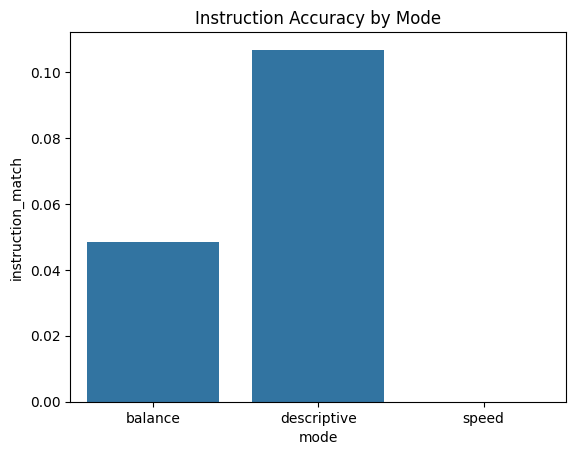

In [43]:
sns.barplot(data=metrics, x="mode", y="instruction_match")
plt.title("Instruction Accuracy by Mode")
plt.show()


### Latency VS Verbosity

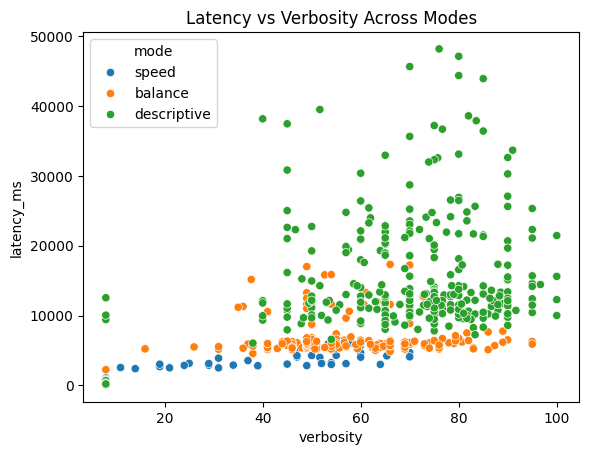

In [44]:
sns.scatterplot(data=df_merged, x="verbosity", y="latency_ms", hue="mode")
plt.title("Latency vs Verbosity Across Modes")
plt.show()


### Latency Per Mode

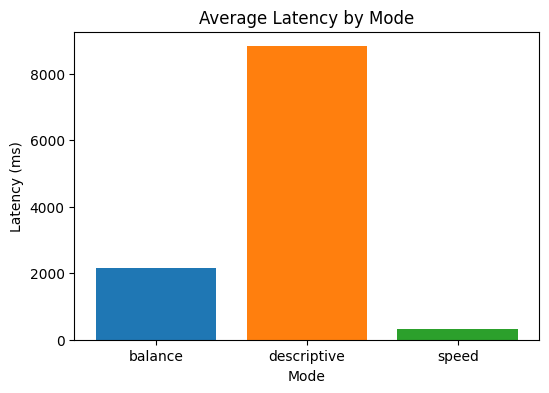

In [45]:
plt.figure(figsize=(6,4))
plt.bar(metrics["mode"], metrics["latency_ms"], color=["#1f77b4","#ff7f0e","#2ca02c"])
plt.title("Average Latency by Mode")
plt.ylabel("Latency (ms)")
plt.xlabel("Mode")
plt.show()

### VLM Usage Rate

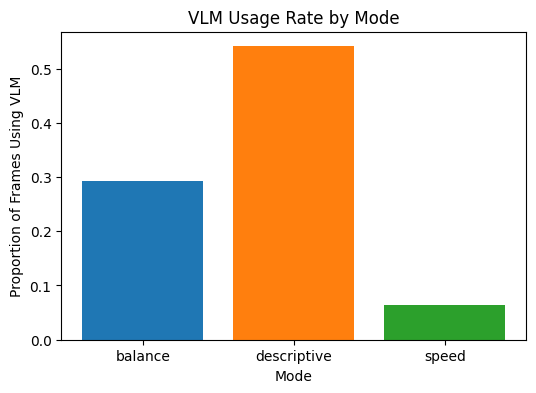

In [46]:
plt.figure(figsize=(6,4))
plt.bar(metrics["mode"], metrics["used_vlm"], color=["#1f77b4","#ff7f0e","#2ca02c"])
plt.title("VLM Usage Rate by Mode")
plt.ylabel("Proportion of Frames Using VLM")
plt.xlabel("Mode")
plt.show()

### Verbosity Distribution 

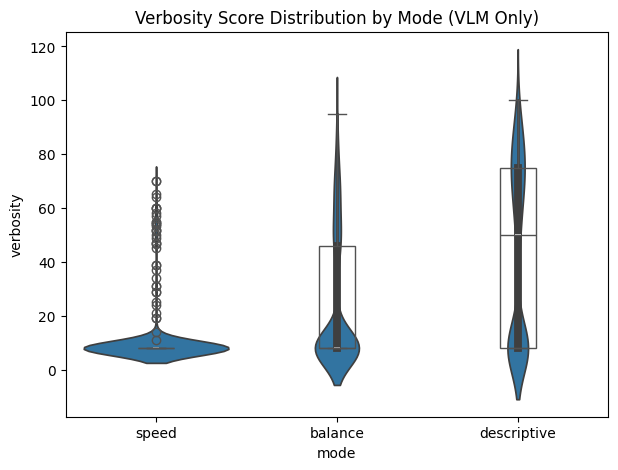

In [47]:
plt.figure(figsize=(7,5))
sns.violinplot(data=df_merged[df_merged["verbosity"].notna()], x="mode", y="verbosity")
sns.boxplot(data=df_merged[df_merged["verbosity"].notna()], x="mode", y="verbosity",
            width=0.2, showcaps=True, boxprops={'facecolor':'None'})
plt.title("Verbosity Score Distribution by Mode (VLM Only)")
plt.show()


### Verbosity Means

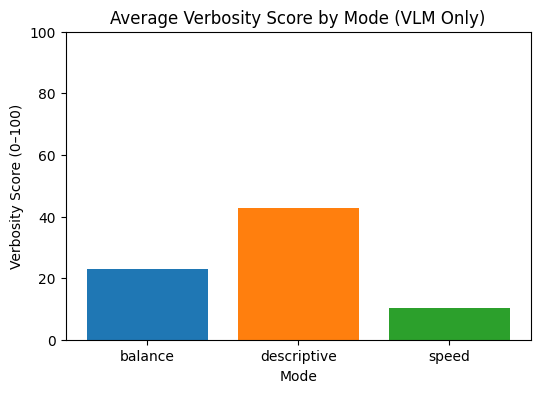

In [48]:
plt.figure(figsize=(6,4))
plt.bar(metrics["mode"], metrics["verbosity"], color=["#1f77b4","#ff7f0e","#2ca02c"])
plt.title("Average Verbosity Score by Mode (VLM Only)")
plt.ylabel("Verbosity Score (0–100)")
plt.xlabel("Mode")
plt.ylim(0,100)
plt.show()

### Mode VS Ground Truth

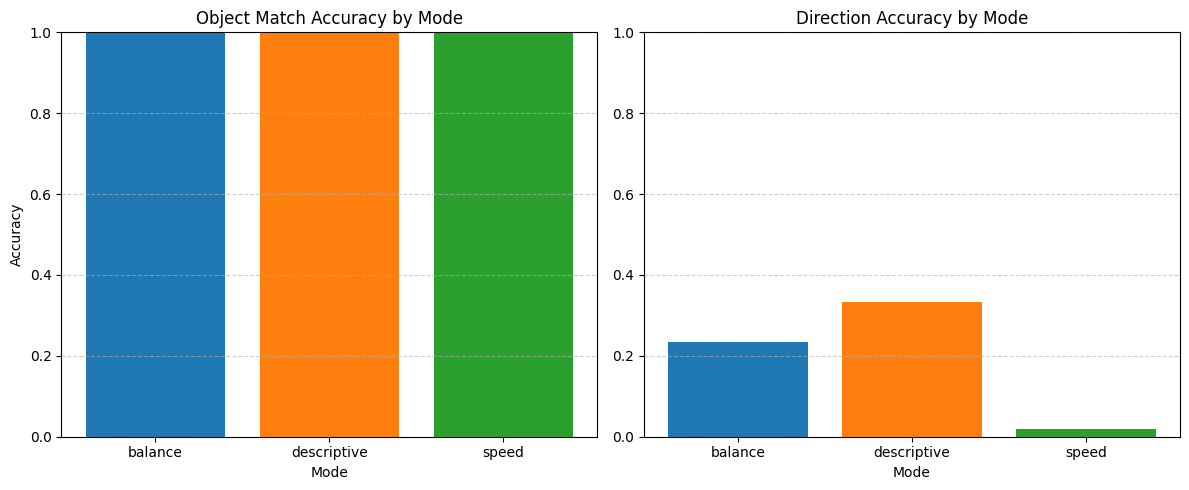

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Extract values
modes = metrics["mode"]
object_acc = metrics["object_match"]
direction_acc = metrics["location_match"]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -----------------------------
# Left: Object Match Accuracy
# -----------------------------
axes[0].bar(modes, object_acc, color=["#1f77b4","#ff7f0e","#2ca02c"])
axes[0].set_title("Object Match Accuracy by Mode")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)

# -----------------------------
# Right: Direction Accuracy
# -----------------------------
axes[1].bar(modes, direction_acc, color=["#1f77b4","#ff7f0e","#2ca02c"])
axes[1].set_title("Direction Accuracy by Mode")
axes[1].set_ylim(0, 1)

# Global styling
for ax in axes:
    ax.set_xlabel("Mode")
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


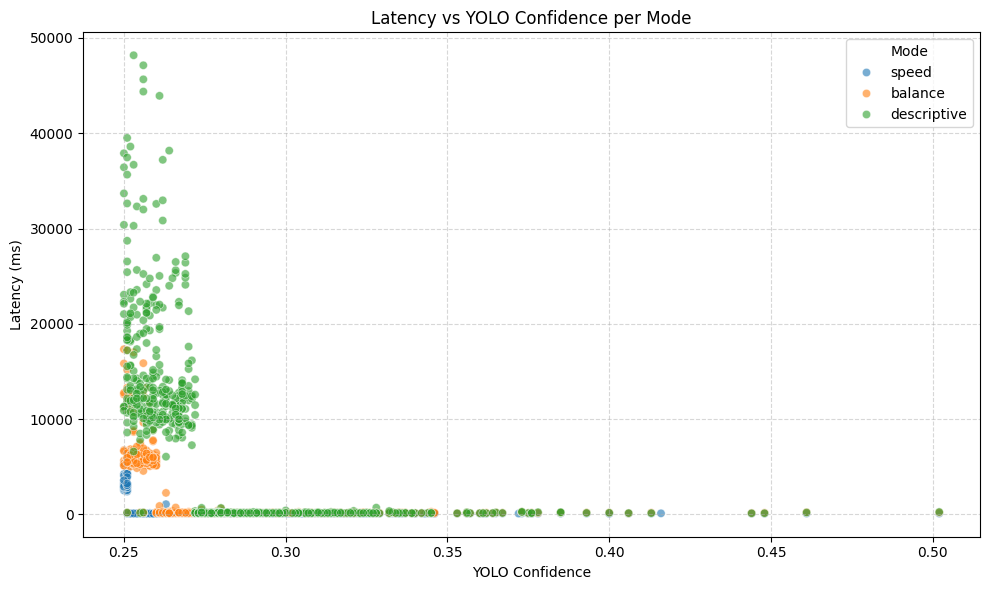

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
speed = pd.read_csv("/Users/rianachatterjee/Downloads/in-lab/output_dir/speed_mode_results_vlm.csv")
balance = pd.read_csv("/Users/rianachatterjee/Downloads/in-lab/output_dir/balance_mode_results_vlm.csv")
desc = pd.read_csv("/Users/rianachatterjee/Downloads/in-lab/output_dir/descriptive_mode_results_vlm.csv")

# Label modes
speed["mode"] = "speed"
balance["mode"] = "balance"
desc["mode"] = "descriptive"

# Combine
df = pd.concat([speed, balance, desc], ignore_index=True)

# ---- Plot: Latency vs YOLO Confidence Per Mode ----
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="yolo_confidence",
    y="latency_ms",
    hue="mode",
    alpha=0.6
)

plt.title("Latency vs YOLO Confidence per Mode")
plt.xlabel("YOLO Confidence")
plt.ylabel("Latency (ms)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Mode")

plt.tight_layout()
plt.show()
